In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# STEP 1: Imports and environment check

import os
import zipfile
import shutil
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("Current folder:", os.getcwd())
print("Files in folder:", os.listdir())
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

Current folder: /content
Files in folder: ['.config', 'drive', 'sample_data']
TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
zip_path="/content/drive/MyDrive/Deeplearning/Sports.zip"

In [ ]:
# ============================================================
# STEP 2: Extract Dataset from Google Drive
# ============================================================

import os
import zipfile

zip_path = "/content/drive/MyDrive/Deeplearning/Sports.zip"
extract_path = "/content/data"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction done.")
else:
    print("Dataset already extracted.")

print("Extracted folder contents:")
print(os.listdir(extract_path))

Extraction done.
Extracted folder contents:
['data']


In [ ]:
# STEP 3: Check all available classes

data_path = "/content/data/data"

classes = os.listdir(data_path)

print("Total Classes:", len(classes))
print("Class Names:")
print(classes)

Total Classes: 22
Class Names:
['wwe', 'tennis', 'baseball', 'cricket', 'table_tennis', 'chess', 'football', 'boxing', 'volleyball', 'basketball', 'wrestling', 'badminton', 'hockey', 'shooting', 'weight_lifting', 'motogp', 'formula1', 'kabaddi', 'gymnastics', 'fencing', 'ice_hockey', 'swimming']


In [ ]:
# STEP 4: Create selected 12-class dataset

selected_classes = [
    "badminton",
    "basketball",
    "football",
    "cricket",
    "table_tennis",
    "swimming",
    "shooting",
    "formula1",
    "boxing",
    "volleyball",
    "chess",
    "hockey"
]

source_path = "/content/data/data"
target_path = "/content/selected_dataset"

os.makedirs(target_path, exist_ok=True)

for class_name in selected_classes:
    src = os.path.join(source_path, class_name)
    dst = os.path.join(target_path, class_name)

    if not os.path.exists(src):
        print("Missing class folder:", src)
        continue

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

print("Selected dataset created.")
print("Total selected classes:", len(os.listdir(target_path)))
print("Selected classes:")

for cls in os.listdir(target_path):
    print("-", cls)

Selected dataset created.
Total selected classes: 12
Selected classes:
- cricket
- table_tennis
- chess
- football
- boxing
- volleyball
- basketball
- badminton
- hockey
- shooting
- formula1
- swimming


In [ ]:
# STEP 5: Count images in selected 12-class dataset

target_path = "/content/selected_dataset"
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in selected_classes:
    class_path = os.path.join(target_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    class_counts[class_name] = len(images)

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print(df_counts)
print("\nTotal Images:", df_counts["Number of Images"].sum())
print("Number of Classes:", len(df_counts))

           Class  Number of Images
0      badminton               917
1     basketball               481
2       football               776
3        cricket               656
4   table_tennis               696
5       swimming               675
6       shooting               523
7       formula1               668
8         boxing               695
9     volleyball               690
10         chess               468
11        hockey               559

Total Images: 7804
Number of Classes: 12


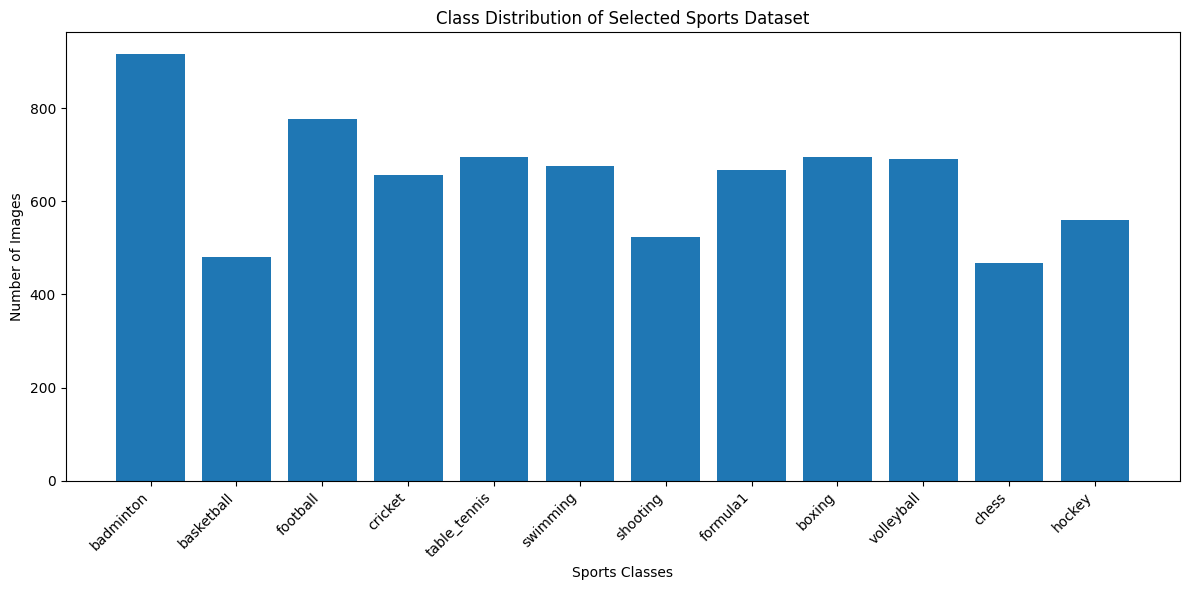

In [ ]:
# STEP 6: Visualize class distribution

plt.figure(figsize=(12, 6))
plt.bar(df_counts["Class"], df_counts["Number of Images"])
plt.xlabel("Sports Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Selected Sports Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

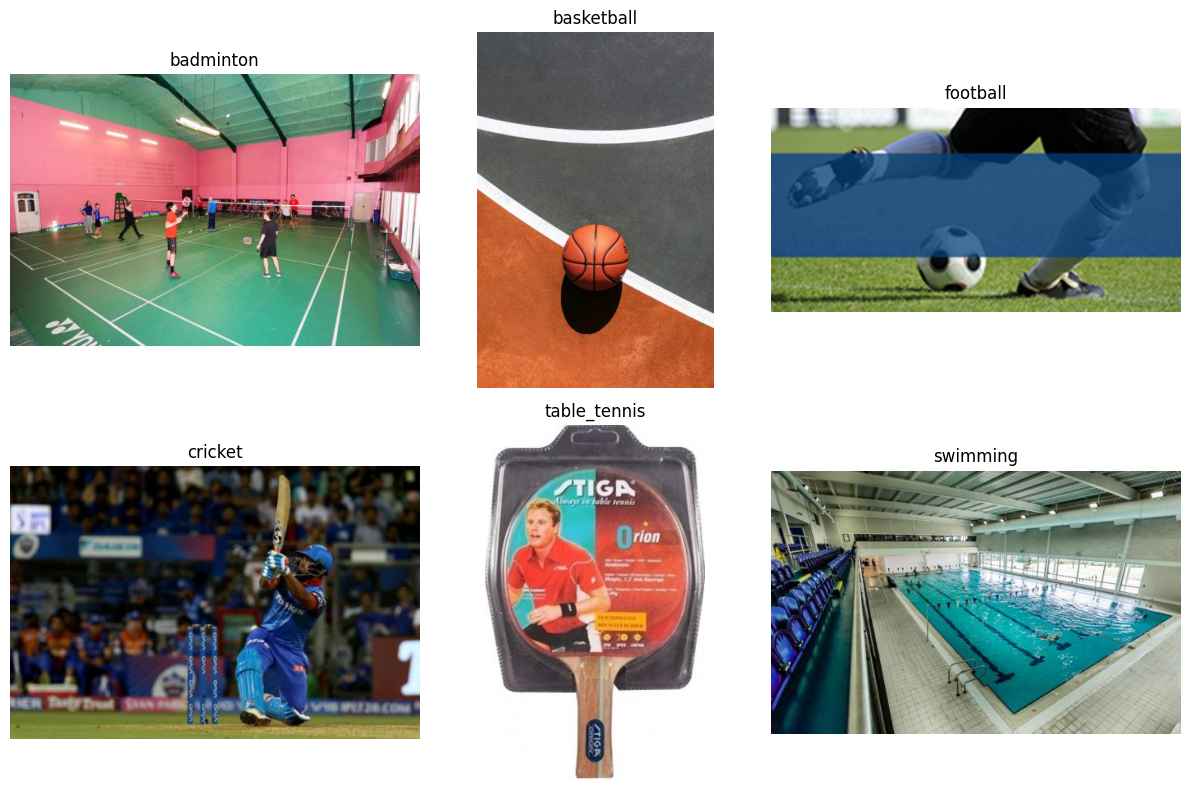

In [ ]:
# STEP 6: Display sample images from each class

import cv2
import random

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(selected_classes[:6]):  # show 6 classes
    class_path = os.path.join(target_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# STEP 7: Split selected dataset into train, validation, and test sets

source_dir = "selected_dataset"
output_dir = "data"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

for class_name in selected_classes:
    class_path = os.path.join(source_dir, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    for split_name, split_imgs in {
        "train": train_imgs,
        "val": val_imgs,
        "test": test_imgs
    }.items():
        split_class_path = os.path.join(output_dir, split_name, class_name)
        os.makedirs(split_class_path, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_path, img)
            shutil.copy(src, dst)

print("Dataset split completed.")
print(os.listdir(output_dir))

Dataset split completed.
['train', 'test', 'val']


In [ ]:
# STEP 8: Verify train/val/test image counts

split_counts = []

for split in ["train", "val", "test"]:
    split_path = os.path.join("data", split)

    for class_name in selected_classes:
        class_path = os.path.join(split_path, class_name)

        images = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        ]

        split_counts.append({
            "Split": split,
            "Class": class_name,
            "Images": len(images)
        })

df_split_counts = pd.DataFrame(split_counts)

print(df_split_counts)

print("\nTotal per split:")
print(df_split_counts.groupby("Split")["Images"].sum())

    Split         Class  Images
0   train     badminton     641
1   train    basketball     336
2   train      football     543
3   train       cricket     459
4   train  table_tennis     487
5   train      swimming     472
6   train      shooting     366
7   train      formula1     467
8   train        boxing     486
9   train    volleyball     483
10  train         chess     327
11  train        hockey     391
12    val     badminton     138
13    val    basketball      72
14    val      football     116
15    val       cricket      98
16    val  table_tennis     104
17    val      swimming     101
18    val      shooting      78
19    val      formula1     100
20    val        boxing     104
21    val    volleyball     103
22    val         chess      70
23    val        hockey      84
24   test     badminton     138
25   test    basketball      73
26   test      football     117
27   test       cricket      99
28   test  table_tennis     105
29   test      swimming     102
30   tes

In [ ]:
# ============================================================
# Phase 3: Preprocessing and Data Augmentation
# Step 9: Create Image Generators
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "data/train"
val_dir = "data/val"
test_dir = "data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:")
print(train_generator.class_indices)

Found 5454 images belonging to 12 classes.
Found 1168 images belonging to 12 classes.
Found 1177 images belonging to 12 classes.
Class indices:
{'badminton': 0, 'basketball': 1, 'boxing': 2, 'chess': 3, 'cricket': 4, 'football': 5, 'formula1': 6, 'hockey': 7, 'shooting': 8, 'swimming': 9, 'table_tennis': 10, 'volleyball': 11}


In [ ]:
# Check unreadable/corrupted images in train folder

from PIL import Image

bad_files = []

for class_name in selected_classes:
    class_path = os.path.join("data/train", class_name)

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            bad_files.append(file_path)

print("Bad files found:", len(bad_files))
for f in bad_files:
    print(f)

Bad files found: 0


In [ ]:
# Check image extensions in selected dataset

from collections import Counter
import os

target_path = "/content/selected_dataset"

ext_counts = Counter()

for class_name in selected_classes:
    class_path = os.path.join(target_path, class_name)

    for file in os.listdir(class_path):
        ext = os.path.splitext(file)[1].lower()
        ext_counts[ext] += 1

print(ext_counts)

Counter({'.jpg': 7187, '.jpeg': 314, '.png': 296, '.ashx': 47, '.gif': 19, '.aspx': 17, '.php': 14, '.img': 5, '.webp': 5, '.cms': 4, '.5': 2, '.bmp': 2, '.bin': 1, '.axd': 1, '.asmx': 1, '.cls': 1})


In [ ]:
# Remove unsupported .webp files for Keras flow_from_directory

removed_files = []

for split in ["train", "val", "test"]:
    for class_name in selected_classes:
        class_path = os.path.join("data", split, class_name)

        for file in os.listdir(class_path):
            if file.lower().endswith(".webp"):
                file_path = os.path.join(class_path, file)
                os.remove(file_path)
                removed_files.append(file_path)

print("Removed unsupported .webp files:", len(removed_files))

Removed unsupported .webp files: 5


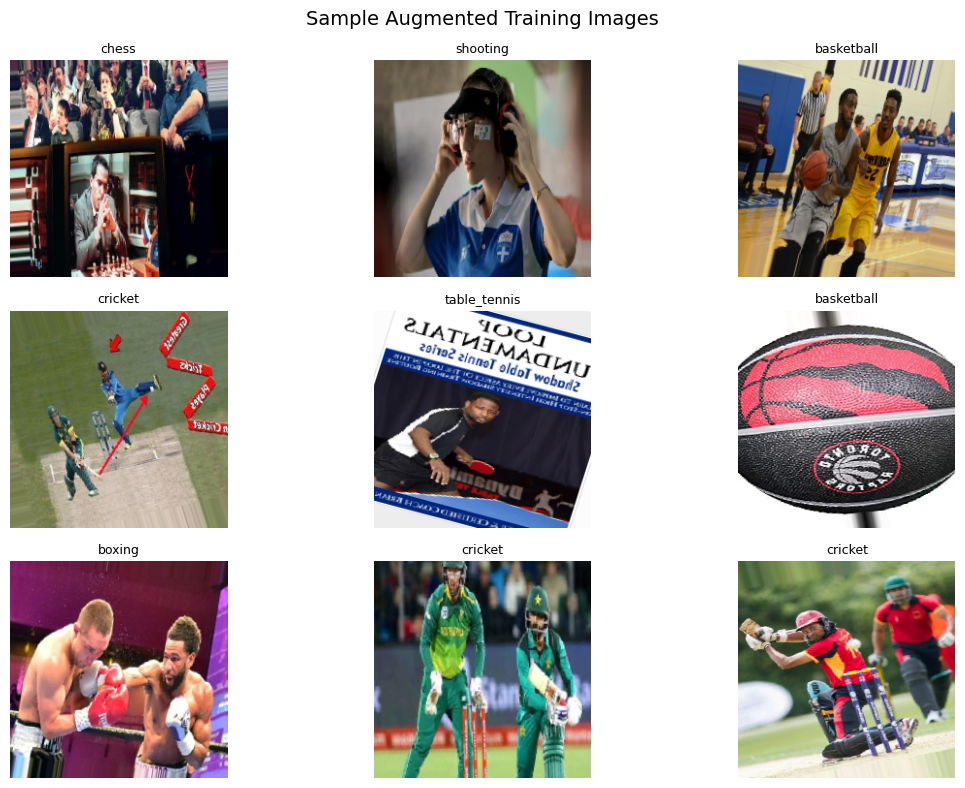

In [ ]:
# Get one real image batch from generator
batch_images, batch_labels = next(train_generator)

class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch_images[i])
    plt.title(class_labels[np.argmax(batch_labels[i])], fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 4: Baseline CNN Model
# Step 11: Build Baseline CNN Architecture
# ============================================================

NUM_CLASSES = len(train_generator.class_indices)

baseline_model = models.Sequential([
    # Input Layer
    layers.Input(shape=(224, 224, 3)),

    # Convolution + Pooling Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution + Pooling Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution + Pooling Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    # Output Layer
    layers.Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,604 (85.02 MB)

 Trainable params: 22,286,604 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Phase 5: Train Baseline CNN
# Step 12: Train Baseline Model
# ============================================================

EPOCHS = 20

baseline_start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

baseline_training_time = time.time() - baseline_start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 90s 474ms/step - accuracy: 0.2862 - loss: 2.1024 - val_accuracy: 0.4161 - val_loss: 1.7806
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 428ms/step - accuracy: 0.4606 - loss: 1.6067 - val_accuracy: 0.4820 - val_loss: 1.5445
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 427ms/step - accuracy: 0.5277 - loss: 1.4267 - val_accuracy: 0.5634 - val_loss: 1.3742
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 76s 441ms/step - accuracy: 0.5783 - loss: 1.3155 - val_accuracy: 0.5642 - val_loss: 1.3464
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 74s 434ms/step - accuracy: 0.5974 - loss: 1.2219 - val_accuracy: 0.5882 - val_loss: 1.3158
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 427ms/step - accuracy: 0.6190 - loss: 1.1534 - val_accuracy: 0.6147 - val_loss: 1.2766
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 429ms/step - accuracy: 0.6406 - loss: 1.0931 - val_accuracy: 0.5985 - val_loss: 1.2716
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 75s 436ms/step - accuracy: 0.6522 - loss: 1

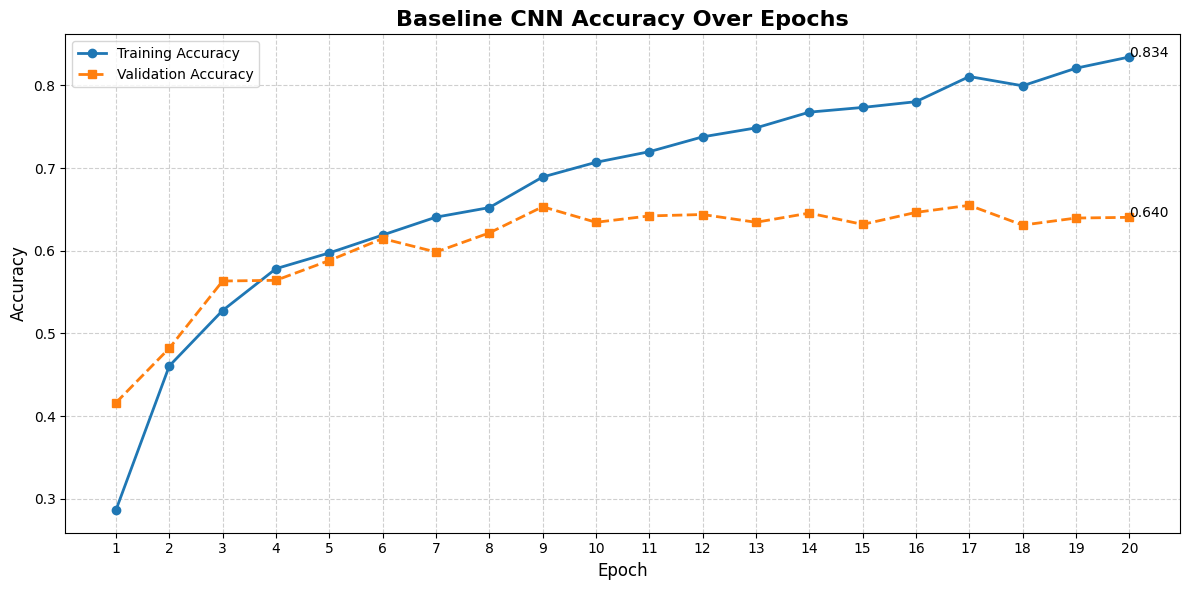

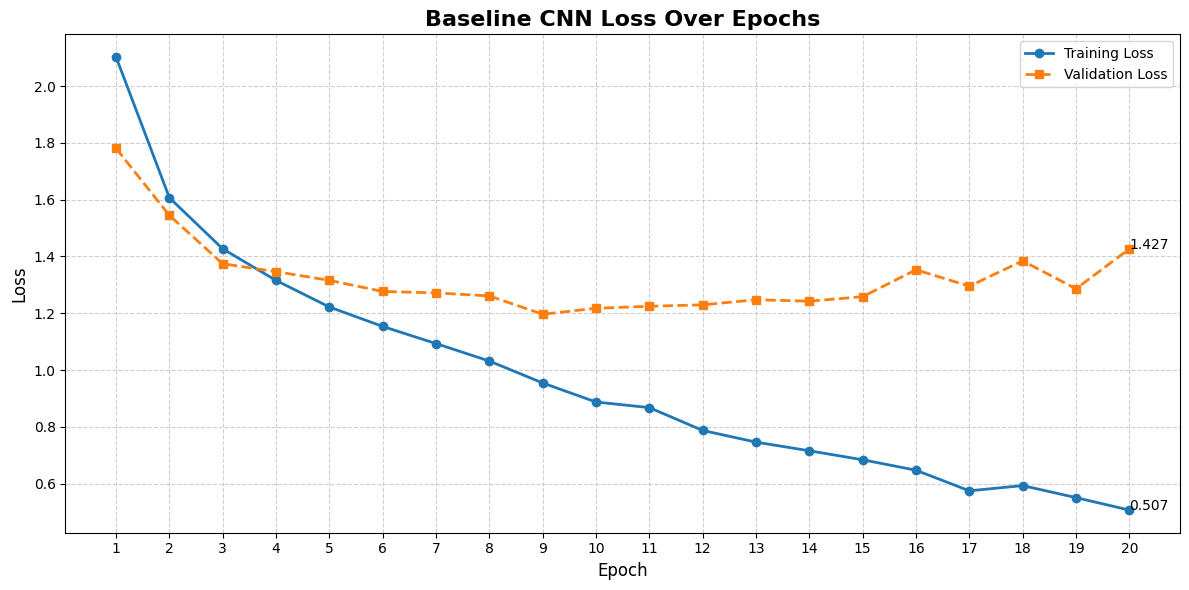

In [ ]:
# ============================================================
# Phase 5: Baseline Training Visualization (Premium Version)
# Step 13: Plot Accuracy and Loss Curves
# ============================================================

import matplotlib.pyplot as plt

# Extract history
acc = baseline_history.history.get("accuracy", [])
val_acc = baseline_history.history.get("val_accuracy", [])
loss = baseline_history.history.get("loss", [])
val_loss = baseline_history.history.get("val_loss", [])

epochs_range = range(1, len(acc) + 1)

# =========================
# Accuracy Plot
# =========================
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, acc, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="s", linewidth=2, linestyle="--", label="Validation Accuracy")

plt.title("Baseline CNN Accuracy Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last value (nice touch 🔥)
if acc:
    plt.text(len(acc), acc[-1], f"{acc[-1]:.3f}", fontsize=10)
if val_acc:
    plt.text(len(val_acc), val_acc[-1], f"{val_acc[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# Loss Plot
# =========================
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs_range, val_loss, marker="s", linewidth=2, linestyle="--", label="Validation Loss")

plt.title("Baseline CNN Loss Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last value
if loss:
    plt.text(len(loss), loss[-1], f"{loss[-1]:.3f}", fontsize=10)
if val_loss:
    plt.text(len(val_loss), val_loss[-1], f"{val_loss[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 14: Evaluate on Test Data
# ============================================================

test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.6355 - loss: 1.4685
Test Accuracy: 0.6355
Test Loss: 1.4685


In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 15: Generate Predictions
# ============================================================

test_generator.reset()

y_pred_prob = baseline_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Total test images:", len(y_true))
print("Total predictions:", len(y_pred_classes))
print("Class labels:", class_labels)

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step
Total test images: 1177
Total predictions: 1177
Class labels: ['badminton', 'basketball', 'boxing', 'chess', 'cricket', 'football', 'formula1', 'hockey', 'shooting', 'swimming', 'table_tennis', 'volleyball']


In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 16: Classification Report
# ============================================================

print("Baseline CNN Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Baseline CNN Classification Report:
              precision    recall  f1-score   support

   badminton       0.72      0.53      0.61       138
  basketball       0.62      0.48      0.54        73
      boxing       0.85      0.64      0.73       105
       chess       0.53      0.60      0.56        70
     cricket       0.78      0.57      0.65        99
    football       0.60      0.74      0.66       117
    formula1       0.57      0.77      0.66       101
      hockey       0.52      0.56      0.54        84
    shooting       0.48      0.56      0.52        79
    swimming       0.91      0.75      0.82       102
table_tennis       0.58      0.61      0.59       105
  volleyball       0.61      0.76      0.68       104

    accuracy                           0.64      1177
   macro avg       0.65      0.63      0.63      1177
weighted avg       0.66      0.64      0.64      1177



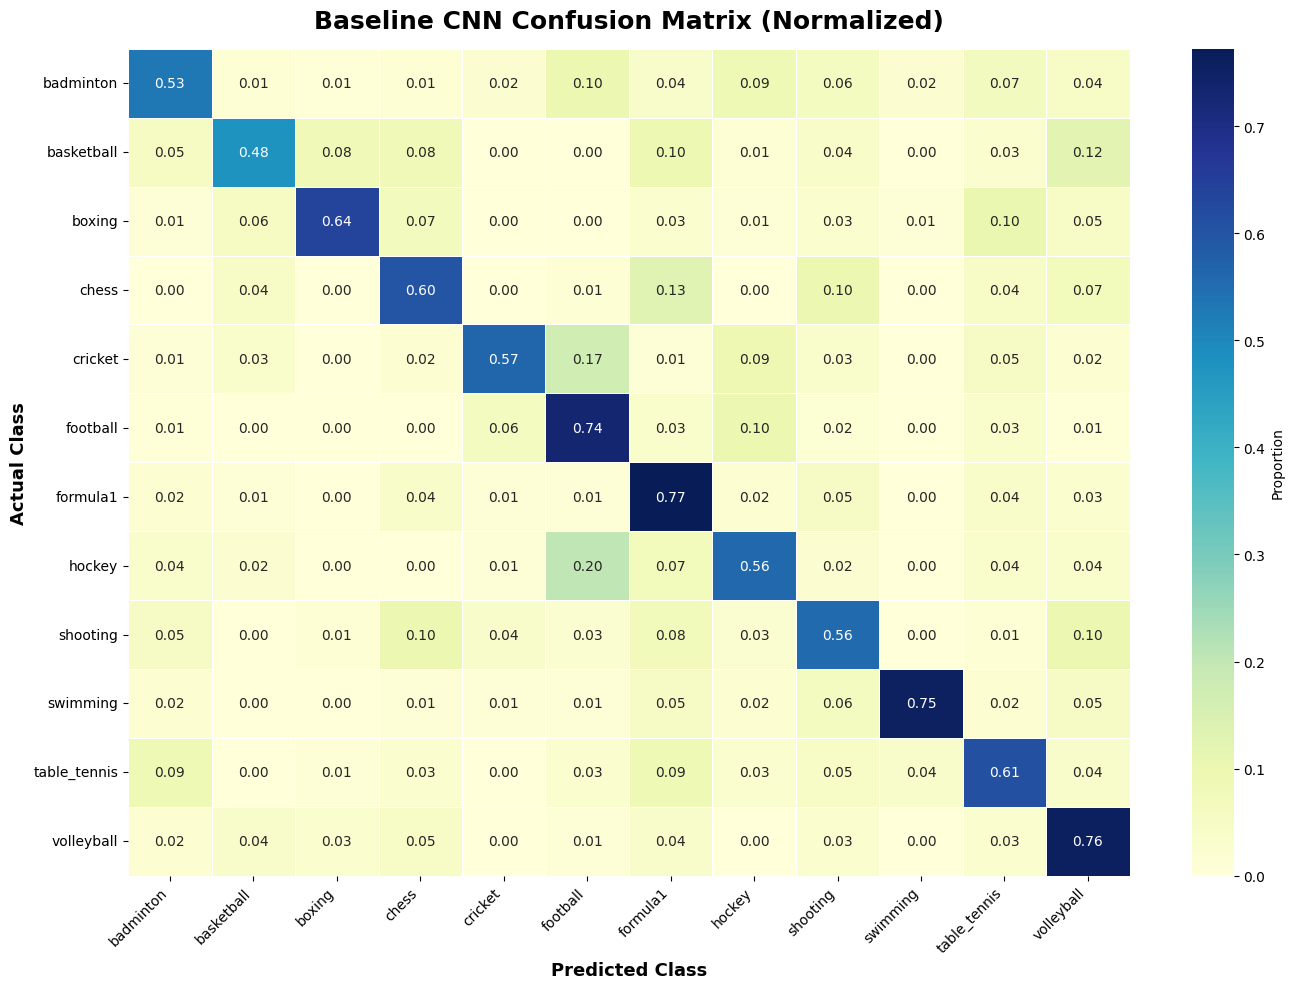

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 17: Confusion Matrix (Final Premium Version)
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize (safe division)
cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("Baseline CNN Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

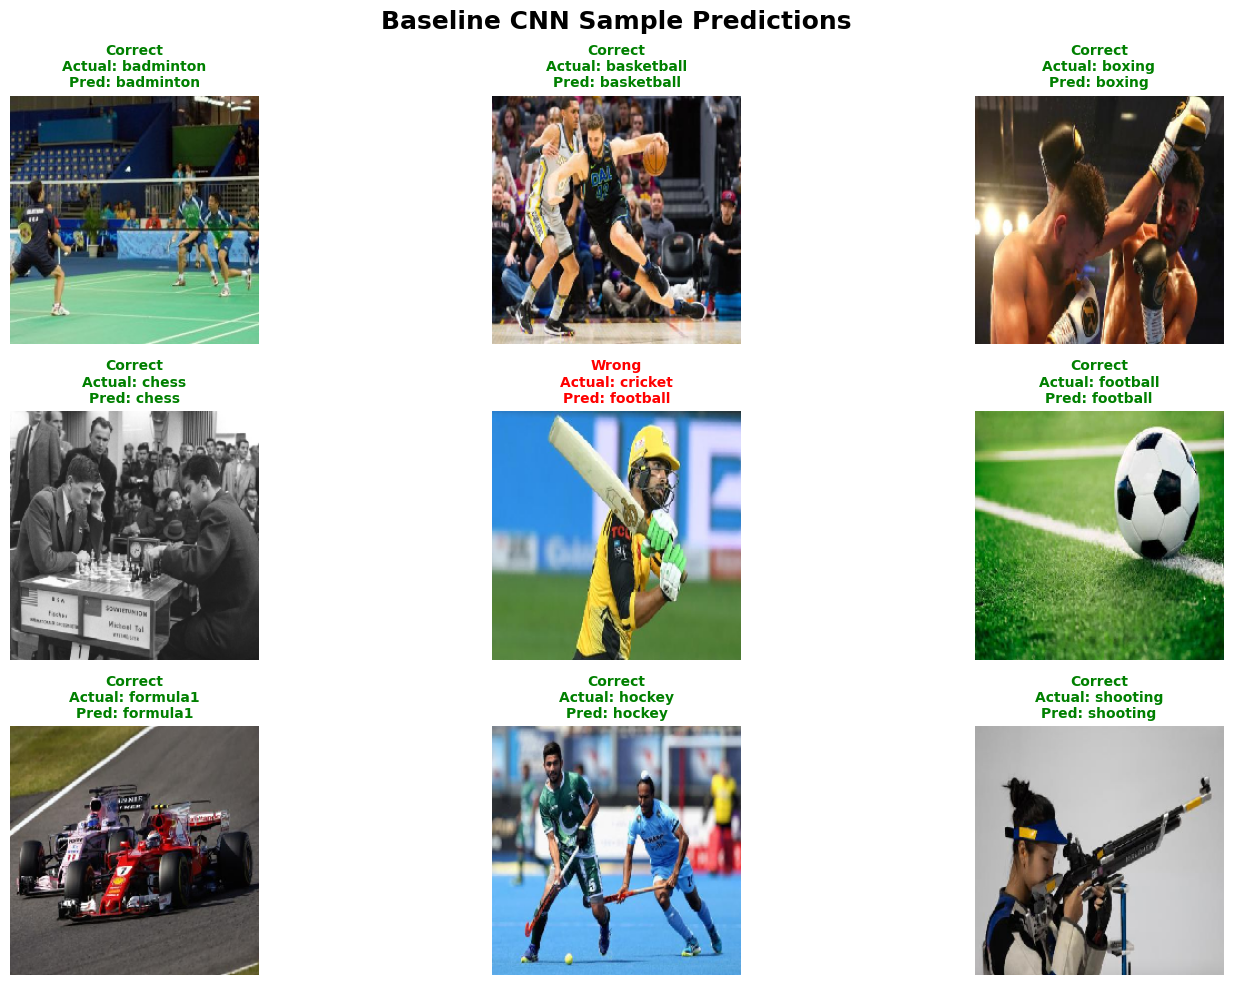

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 18: Sample Predictions - Baseline CNN (Final Version)
# ============================================================

test_generator.reset()

sample_images = []
sample_true_labels = []
sample_pred_labels = []

seen_classes = set()

for images, labels in test_generator:
    pred_probs = baseline_model.predict(images, verbose=0)
    pred_classes = np.argmax(pred_probs, axis=1)
    true_classes = np.argmax(labels, axis=1)

    for i in range(len(images)):
        true_label = class_labels[true_classes[i]]
        pred_label = class_labels[pred_classes[i]]

        # ensure diversity of classes
        if true_label not in seen_classes:
            sample_images.append(images[i])
            sample_true_labels.append(true_label)
            sample_pred_labels.append(pred_label)
            seen_classes.add(true_label)

        if len(sample_images) >= 9:
            break

    if len(sample_images) >= 9:
        break

plt.figure(figsize=(16, 10))

for i in range(len(sample_images)):
    is_correct = sample_true_labels[i] == sample_pred_labels[i]
    status = "Correct" if is_correct else "Wrong"
    title_color = "green" if is_correct else "red"

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])

    plt.title(
        f"{status}\nActual: {sample_true_labels[i]}\nPred: {sample_pred_labels[i]}",
        fontsize=10,
        color=title_color,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle(
    "Baseline CNN Sample Predictions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Model
# Step 19: Build Deeper CNN with Batch Normalization and Dropout
# ============================================================

deep_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.40),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

deep_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,014,636 (99.24 MB)

 Trainable params: 26,013,228 (99.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Model
# Step 20: Train Deeper CNN Model
# ============================================================

EPOCHS = 20

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

deep_start_time = time.time()

deep_history = deep_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop]
)

deep_training_time = time.time() - deep_start_time

print(f"Deep CNN training time: {deep_training_time:.2f} seconds")

Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 124s 576ms/step - accuracy: 0.2554 - loss: 2.5017 - val_accuracy: 0.1490 - val_loss: 2.9114
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 473ms/step - accuracy: 0.3597 - loss: 2.0013 - val_accuracy: 0.2928 - val_loss: 2.3271
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 79s 464ms/step - accuracy: 0.4237 - loss: 1.7650 - val_accuracy: 0.4906 - val_loss: 1.6294
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 474ms/step - accuracy: 0.4655 - loss: 1.6275 - val_accuracy: 0.5428 - val_loss: 1.4106
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 467ms/step - accuracy: 0.4897 - loss: 1.5599 - val_accuracy: 0.5616 - val_loss: 1.3482
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 466ms/step - accuracy: 0.5150 - loss: 1.4903 - val_accuracy: 0.5060 - val_loss: 1.5130
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 468ms/step - accuracy: 0.5326 - loss: 1.4312 - val_accuracy: 0.5651 - val_loss: 1.2900
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 467ms/step - accuracy: 0.5546 - loss: 

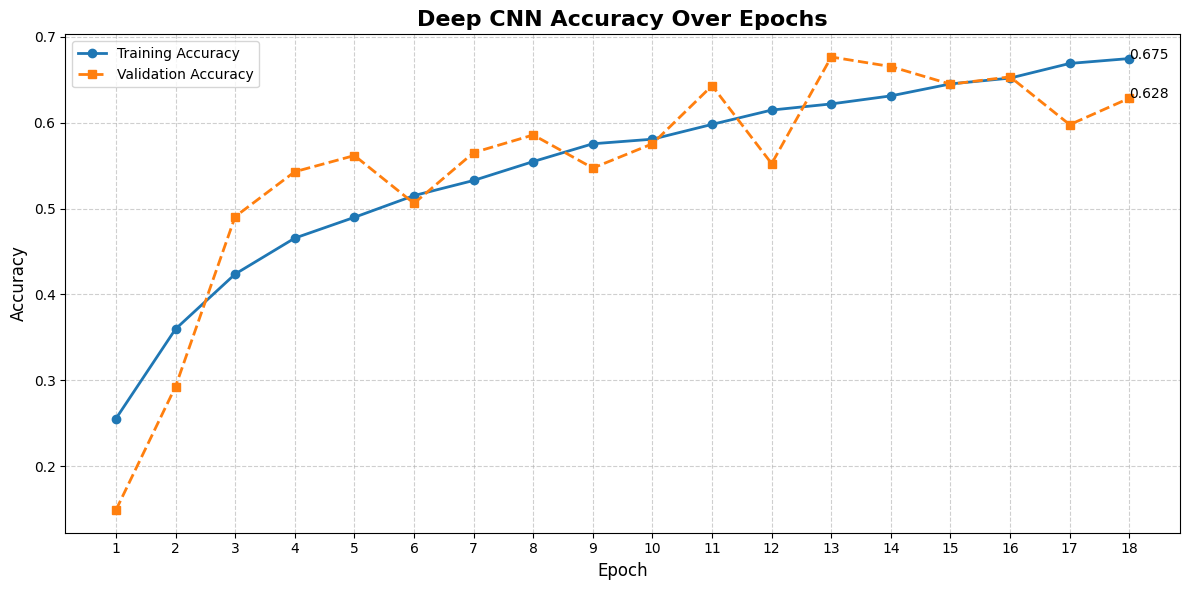

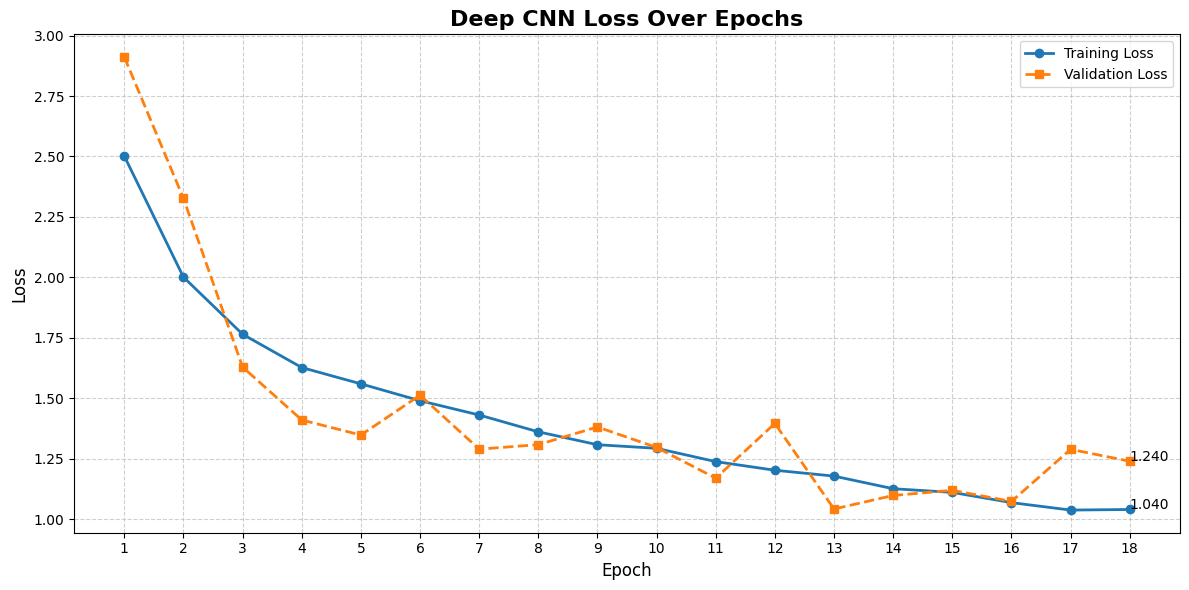

In [ ]:
# ============================================================
# Phase 7: Deep CNN Visualization (Consistent Style)
# ============================================================

import matplotlib.pyplot as plt

# Extract history safely
acc = deep_history.history.get("accuracy", [])
val_acc = deep_history.history.get("val_accuracy", [])
loss = deep_history.history.get("loss", [])
val_loss = deep_history.history.get("val_loss", [])

epochs_range = range(1, len(acc) + 1)

# =========================
# Accuracy Plot
# =========================
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, acc, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="s", linewidth=2, linestyle="--", label="Validation Accuracy")

plt.title("Deep CNN Accuracy Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last values
if acc:
    plt.text(len(acc), acc[-1], f"{acc[-1]:.3f}", fontsize=10)
if val_acc:
    plt.text(len(val_acc), val_acc[-1], f"{val_acc[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# Loss Plot
# =========================
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs_range, val_loss, marker="s", linewidth=2, linestyle="--", label="Validation Loss")

plt.title("Deep CNN Loss Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last values
if loss:
    plt.text(len(loss), loss[-1], f"{loss[-1]:.3f}", fontsize=10)
if val_loss:
    plt.text(len(val_loss), val_loss[-1], f"{val_loss[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 22: Evaluate Deep CNN on Test Data
# ============================================================

print("=" * 70)
print("Evaluating Deep CNN on Test Dataset")
print("=" * 70)

deep_test_loss, deep_test_accuracy = deep_model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("DEEP CNN TEST PERFORMANCE")
print("=" * 70)
print(f"Test Accuracy      : {deep_test_accuracy:.4f}")
print(f"Test Loss          : {deep_test_loss:.4f}")
print(f"Training Time (sec): {deep_training_time:.2f}")
print(f"Training Time (min): {deep_training_time / 60:.2f}")
print("=" * 70)

Evaluating Deep CNN on Test Dataset
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.6559 - loss: 1.1071
DEEP CNN TEST PERFORMANCE
Test Accuracy      : 0.6559
Test Loss          : 1.1071
Training Time (sec): 1500.08
Training Time (min): 25.00


In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 23: Generate Predictions
# ============================================================

import numpy as np

# Reset generator to ensure correct ordering
test_generator.reset()

# Predict
deep_pred_prob = deep_model.predict(
    test_generator,
    verbose=1
)

deep_pred_classes = np.argmax(deep_pred_prob, axis=1)

# True labels
y_true = test_generator.classes

# Class labels (consistent order)
class_labels = list(test_generator.class_indices.keys())

print("=" * 70)
print("DEEP CNN PREDICTION SUMMARY")
print("=" * 70)
print("Total Test Images :", len(y_true))
print("Total Predictions :", len(deep_pred_classes))
print("Number of Classes :", len(class_labels))
print("Class Labels      :", class_labels)
print("=" * 70)

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step
DEEP CNN PREDICTION SUMMARY
Total Test Images : 1177
Total Predictions : 1177
Number of Classes : 12
Class Labels      : ['badminton', 'basketball', 'boxing', 'chess', 'cricket', 'football', 'formula1', 'hockey', 'shooting', 'swimming', 'table_tennis', 'volleyball']


In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 24: Classification Report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

print("=" * 70)
print("DEEP CNN CLASSIFICATION REPORT")
print("=" * 70)

# Generate report
deep_report_dict = classification_report(
    y_true,
    deep_pred_classes,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

# Pretty print
deep_report_df = pd.DataFrame(deep_report_dict).transpose()
print(deep_report_df.round(4))

print("=" * 70)

DEEP CNN CLASSIFICATION REPORT
              precision  recall  f1-score    support
badminton        0.7259  0.7101    0.7179   138.0000
basketball       0.5862  0.6986    0.6375    73.0000
boxing           0.7857  0.7333    0.7586   105.0000
chess            0.5283  0.4000    0.4553    70.0000
cricket          0.8036  0.4545    0.5806    99.0000
football         0.5215  0.8291    0.6403   117.0000
formula1         0.5971  0.8218    0.6917   101.0000
hockey           0.5735  0.4643    0.5132    84.0000
shooting         0.6452  0.5063    0.5674    79.0000
swimming         0.9100  0.8922    0.9010   102.0000
table_tennis     0.7302  0.4381    0.5476   105.0000
volleyball       0.5923  0.7404    0.6581   104.0000
accuracy         0.6559  0.6559    0.6559     0.6559
macro avg        0.6666  0.6407    0.6391  1177.0000
weighted avg     0.6742  0.6559    0.6501  1177.0000


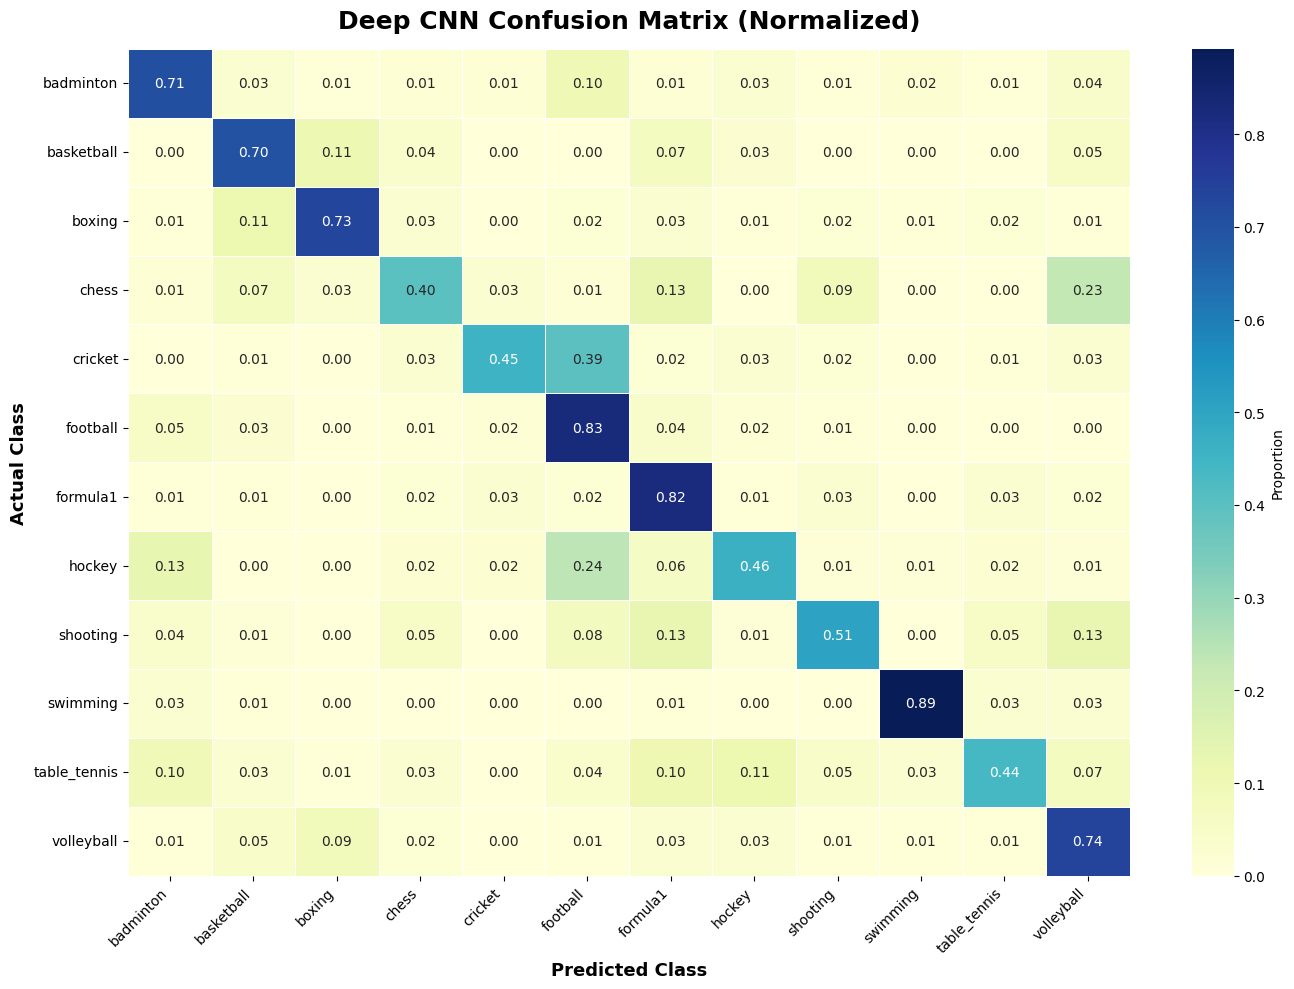

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 25: Confusion Matrix (Final Premium Version)
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm_deep = confusion_matrix(y_true, deep_pred_classes)

# Normalize (safer division)
cm_deep_norm = cm_deep.astype('float') / np.maximum(cm_deep.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_deep_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("Deep CNN Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

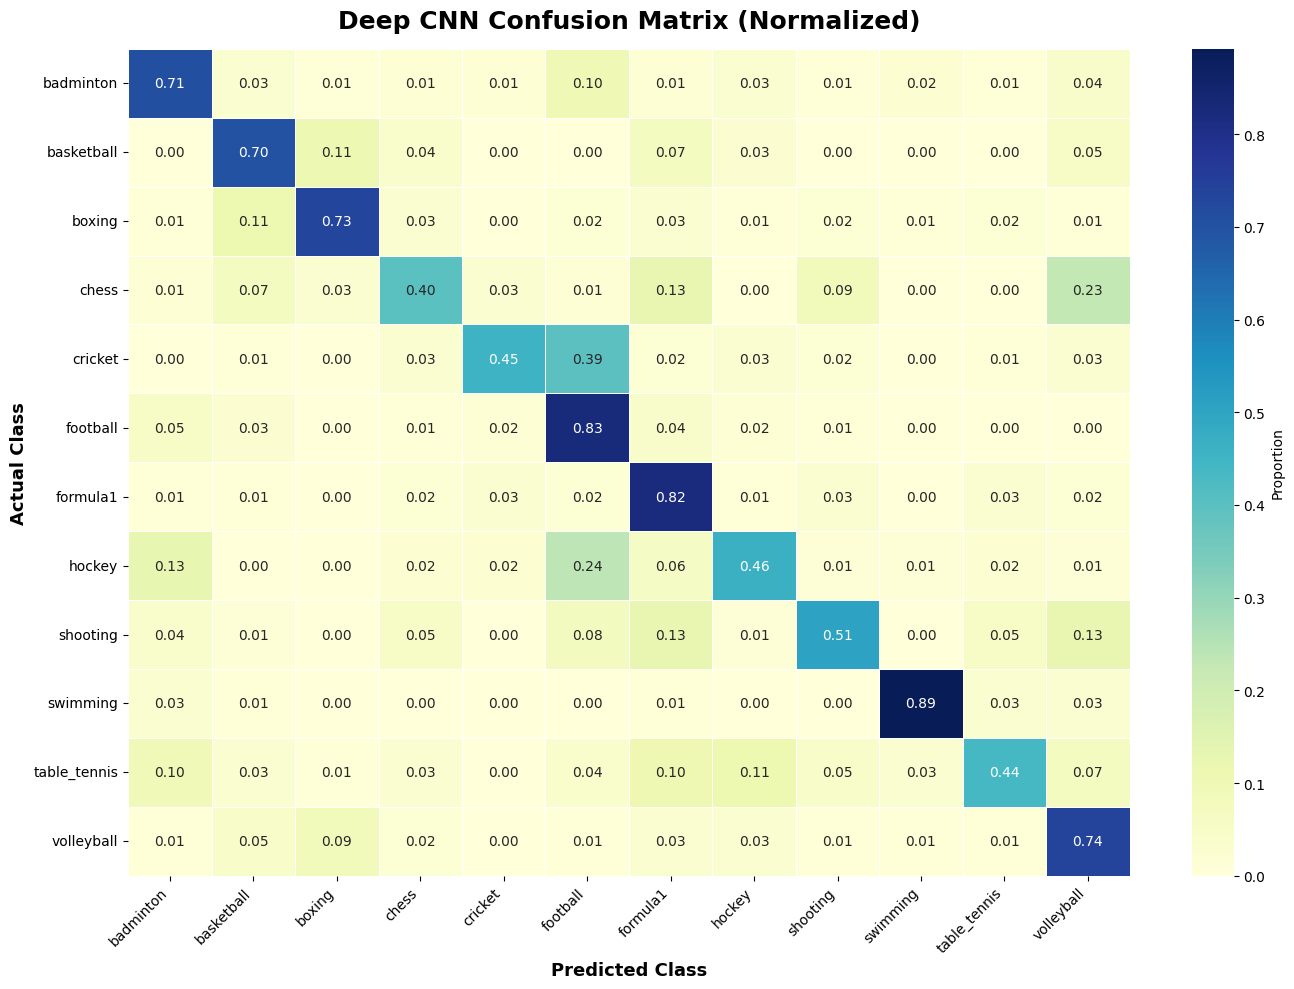

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 25: Confusion Matrix (Final Premium Version)
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm_deep = confusion_matrix(y_true, deep_pred_classes)

# Normalize (safer division)
cm_deep_norm = cm_deep.astype('float') / np.maximum(cm_deep.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_deep_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("Deep CNN Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 7: Baseline vs Deep CNN Comparison
# Step 26: Performance Comparison Table
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline CNN", "Deep CNN"],
    "Train Accuracy": [
        max(baseline_history.history.get("accuracy", [0])),
        max(deep_history.history.get("accuracy", [0]))
    ],
    "Validation Accuracy": [
        max(baseline_history.history.get("val_accuracy", [0])),
        max(deep_history.history.get("val_accuracy", [0]))
    ],
    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy
    ],
    "Test Loss": [
        test_loss,
        deep_test_loss
    ],
    "Training Time (sec)": [
        baseline_training_time,
        deep_training_time
    ]
})

# Round values for clean presentation
comparison = comparison.round({
    "Train Accuracy": 4,
    "Validation Accuracy": 4,
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best test accuracy (optional but looks professional)
comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON (BASELINE vs DEEP CNN)")
print("=" * 70)

comparison

MODEL PERFORMANCE COMPARISON (BASELINE vs DEEP CNN)


,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss,Training Time (sec)
0,Deep CNN,0.6746,0.6764,0.6559,1.1071,1500.08
1,Baseline CNN,0.8344,0.6550,0.6355,1.4685,1497.18


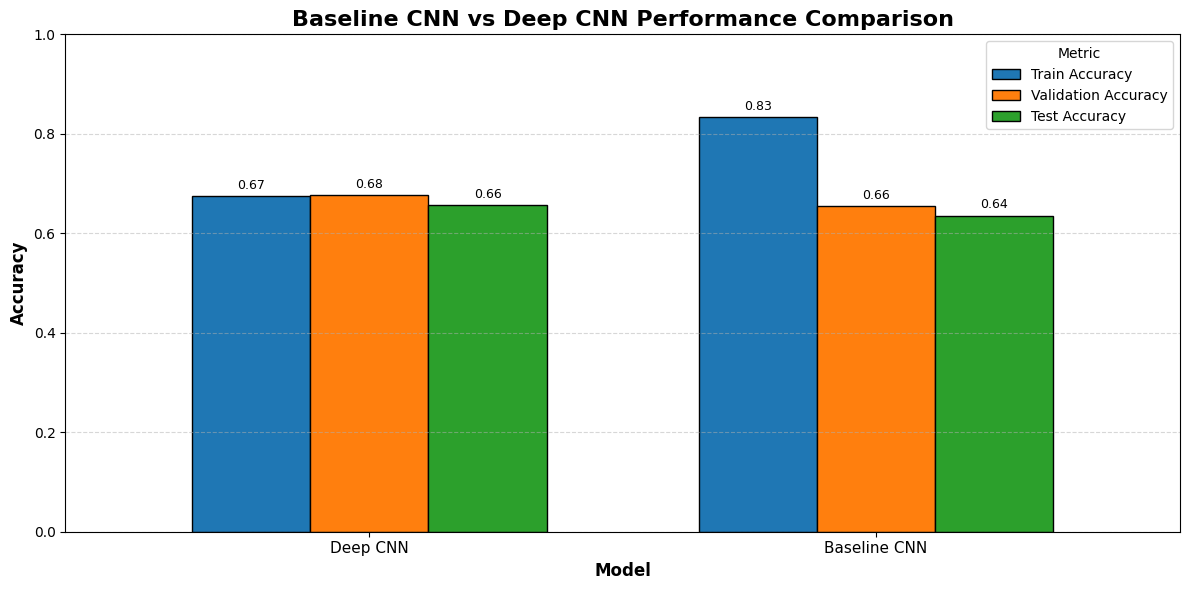

In [ ]:
# ============================================================
# Phase 7: Baseline vs Deep CNN Comparison
# Step 27: Visual Comparison (Final Version)
# ============================================================

import matplotlib.pyplot as plt

metrics_to_plot = ["Train Accuracy", "Validation Accuracy", "Test Accuracy"]

comparison_plot = comparison.set_index("Model")[metrics_to_plot]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.7,
    edgecolor="black"
)

plt.title("Baseline CNN vs Deep CNN Performance Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")

plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=10)

plt.legend(title="Metric", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 28: Build Deep CNN with SGD Optimizer
# ============================================================

from tensorflow.keras.optimizers import SGD

# Rebuild same architecture (clean approach)
deep_model_sgd = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.45),

    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile with SGD
deep_model_sgd.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("DEEP CNN WITH SGD OPTIMIZER")
print("=" * 70)
print("Optimizer : SGD")
print("Learning Rate : 0.01")
print("Momentum : 0.9")
print("=" * 70)

deep_model_sgd.summary()

DEEP CNN WITH SGD OPTIMIZER
Optimizer : SGD
Learning Rate : 0.01
Momentum : 0.9


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 686,252 (2.62 MB)

 Trainable params: 684,332 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 29: Train Deep CNN with SGD Optimizer
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping
import time

EPOCHS_SGD = 20

early_stop_sgd = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("TRAINING DEEP CNN WITH SGD OPTIMIZER")
print("=" * 70)

sgd_start_time = time.time()

sgd_history = deep_model_sgd.fit(
    train_generator,
    epochs=EPOCHS_SGD,
    validation_data=val_generator,
    callbacks=[early_stop_sgd],
    verbose=1
)

sgd_training_time = time.time() - sgd_start_time

print("=" * 70)
print("SGD MODEL TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time (sec): {sgd_training_time:.2f}")
print(f"Training Time (min): {sgd_training_time / 60:.2f}")
print("=" * 70)

TRAINING DEEP CNN WITH SGD OPTIMIZER
Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 105s 539ms/step - accuracy: 0.2547 - loss: 2.4320 - val_accuracy: 0.2971 - val_loss: 2.1384
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 475ms/step - accuracy: 0.3396 - loss: 1.9745 - val_accuracy: 0.4135 - val_loss: 1.7499
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 475ms/step - accuracy: 0.3724 - loss: 1.8924 - val_accuracy: 0.4204 - val_loss: 1.7038
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 476ms/step - accuracy: 0.3878 - loss: 1.8031 - val_accuracy: 0.4307 - val_loss: 1.7033
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 478ms/step - accuracy: 0.4100 - loss: 1.7733 - val_accuracy: 0.4341 - val_loss: 1.6347
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 476ms/step - accuracy: 0.4223 - loss: 1.7155 - val_accuracy: 0.4503 - val_loss: 1.6244
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 485ms/step - accuracy: 0.4360 - loss: 1.6773 - val_accuracy: 0.4529 - val_loss: 1.5929
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 4

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 30: Evaluate SGD Model on Test Data
# ============================================================

print("=" * 70)
print("Evaluating Deep CNN (SGD) on Test Dataset")
print("=" * 70)

sgd_test_loss, sgd_test_accuracy = deep_model_sgd.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("SGD MODEL TEST PERFORMANCE")
print("=" * 70)
print(f"Test Accuracy      : {sgd_test_accuracy:.4f}")
print(f"Test Loss          : {sgd_test_loss:.4f}")
print(f"Training Time (sec): {sgd_training_time:.2f}")
print(f"Training Time (min): {sgd_training_time / 60:.2f}")
print("=" * 70)

Evaluating Deep CNN (SGD) on Test Dataset
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.5013 - loss: 1.4360
SGD MODEL TEST PERFORMANCE
Test Accuracy      : 0.5013
Test Loss          : 1.4360
Training Time (sec): 1497.03
Training Time (min): 24.95


In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 31: Optimizer Comparison Table
# ============================================================

import pandas as pd

optimizer_comparison = pd.DataFrame({
    "Optimizer": ["Adam", "SGD"],
    "Test Accuracy": [deep_test_accuracy, sgd_test_accuracy],
    "Test Loss": [deep_test_loss, sgd_test_loss],
    "Training Time (sec)": [deep_training_time, sgd_training_time]
})

# Round nicely
optimizer_comparison = optimizer_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best accuracy (looks professional)
optimizer_comparison = optimizer_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("OPTIMIZER COMPARISON (ADAM vs SGD)")
print("=" * 70)

optimizer_comparison

OPTIMIZER COMPARISON (ADAM vs SGD)


,Optimizer,Test Accuracy,Test Loss,Training Time (sec)
0,Adam,0.6559,1.1071,1500.08
1,SGD,0.5013,1.4360,1497.03


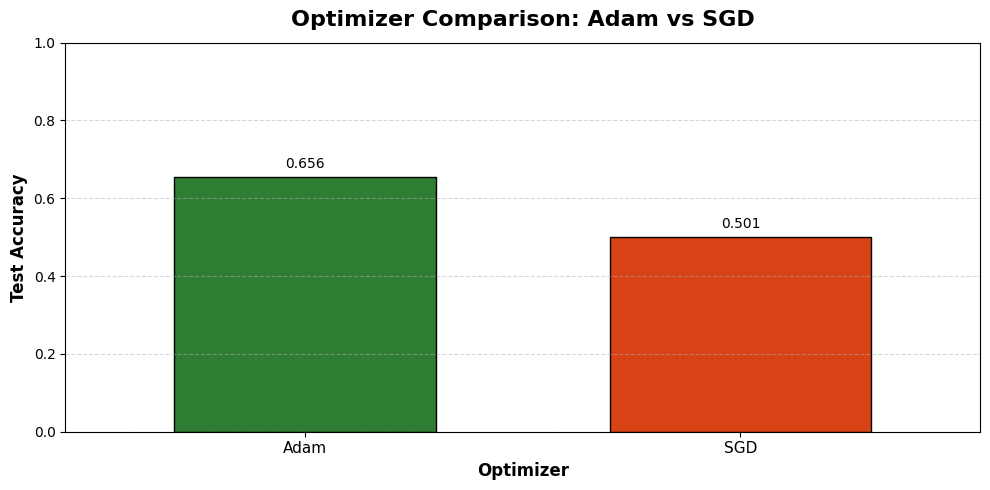

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment
# Step 32: Optimizer Performance Visualization (Final)
# ============================================================

import matplotlib.pyplot as plt

ax = optimizer_comparison.set_index("Optimizer")["Test Accuracy"].plot(
    kind="bar",
    color=["#2E7D32", "#D84315"],
    figsize=(10, 5),
    width=0.6,
    edgecolor="black"
)

plt.title("Optimizer Comparison: Adam vs SGD", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Optimizer", fontsize=12, fontweight="bold")
plt.ylabel("Test Accuracy", fontsize=12, fontweight="bold")

plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 33: Build Deep CNN WITHOUT Dropout
# ============================================================

deep_model_no_dropout = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4 (same as deep model)
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classifier (NO Dropout)
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

deep_model_no_dropout.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("ABLATION MODEL: DEEP CNN WITHOUT DROPOUT")
print("=" * 70)
print("Only Dropout removed — all other layers unchanged")
print("=" * 70)

deep_model_no_dropout.summary()

ABLATION MODEL: DEEP CNN WITHOUT DROPOUT
Only Dropout removed — all other layers unchanged


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,02

 Total params: 686,252 (2.62 MB)

 Trainable params: 684,332 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 34: Train Deep CNN WITHOUT Dropout
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS_ABLATION = 10

early_stop_no_dropout = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("TRAINING ABLATION MODEL: DEEP CNN WITHOUT DROPOUT")
print("=" * 70)

no_dropout_start = time.time()

history_no_dropout = deep_model_no_dropout.fit(
    train_generator,
    epochs=EPOCHS_ABLATION,
    validation_data=val_generator,
    callbacks=[early_stop_no_dropout],
    verbose=1
)

no_dropout_time = time.time() - no_dropout_start

print("=" * 70)
print("NO DROPOUT ABLATION MODEL TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time (sec): {no_dropout_time:.2f}")
print(f"Training Time (min): {no_dropout_time / 60:.2f}")
print("=" * 70)

TRAINING ABLATION MODEL: DEEP CNN WITHOUT DROPOUT
Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 97s 505ms/step - accuracy: 0.4041 - loss: 1.8104 - val_accuracy: 0.1113 - val_loss: 3.6546
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 471ms/step - accuracy: 0.4820 - loss: 1.5588 - val_accuracy: 0.2663 - val_loss: 2.3619
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 467ms/step - accuracy: 0.5205 - loss: 1.4548 - val_accuracy: 0.5257 - val_loss: 1.4865
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 472ms/step - accuracy: 0.5497 - loss: 1.3601 - val_accuracy: 0.4709 - val_loss: 1.7639
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 469ms/step - accuracy: 0.5750 - loss: 1.2773 - val_accuracy: 0.3630 - val_loss: 2.3526
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 79s 463ms/step - accuracy: 0.5985 - loss: 1.2049 - val_accuracy: 0.4666 - val_loss: 1.8057
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
NO DROPOUT ABLATION MODEL TRAINING COMPLETED
Training Time (sec): 498.75
Training

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 35: Evaluate Deep CNN WITHOUT Dropout
# ============================================================

print("=" * 70)
print("Evaluating Ablation Model: Deep CNN WITHOUT Dropout")
print("=" * 70)

no_dropout_loss, no_dropout_accuracy = deep_model_no_dropout.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("NO DROPOUT MODEL TEST PERFORMANCE")
print("=" * 70)
print(f"Test Accuracy      : {no_dropout_accuracy:.4f}")
print(f"Test Loss          : {no_dropout_loss:.4f}")
print(f"Training Time (sec): {no_dropout_time:.2f}")
print(f"Training Time (min): {no_dropout_time / 60:.2f}")
print("=" * 70)

Evaluating Ablation Model: Deep CNN WITHOUT Dropout
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.5132 - loss: 1.5163
NO DROPOUT MODEL TEST PERFORMANCE
Test Accuracy      : 0.5132
Test Loss          : 1.5163
Training Time (sec): 498.75
Training Time (min): 8.31


In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 36: Dropout Ablation Comparison
# ============================================================

ablation_comparison = pd.DataFrame({
    "Model": ["Deep CNN with Dropout", "Deep CNN without Dropout"],
    "Test Accuracy": [deep_test_accuracy, no_dropout_accuracy],
    "Test Loss": [deep_test_loss, no_dropout_loss],
    "Training Time (sec)": [deep_training_time, no_dropout_time]
})

ablation_comparison = ablation_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

print("=" * 70)
print("DROPOUT ABLATION COMPARISON")
print("=" * 70)

ablation_comparison

DROPOUT ABLATION COMPARISON


,Model,Test Accuracy,Test Loss,Training Time (sec)
0,Deep CNN with Dropout,0.6559,1.1071,1500.08
1,Deep CNN without Dropout,0.5132,1.5163,498.75


In [ ]:
# ============================================================
# Phase 8: Final Model Comparison Table (Polished Version)
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN (Adam)",
        "Deep CNN (SGD)",
        "Deep CNN (No Dropout)"
    ],
    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy,
        sgd_test_accuracy,
        no_dropout_accuracy
    ],
    "Test Loss": [
        test_loss,
        deep_test_loss,
        sgd_test_loss,
        no_dropout_loss
    ],
    "Training Time (sec)": [
        baseline_training_time,
        deep_training_time,
        sgd_training_time,
        no_dropout_time
    ]
})

# Clean formatting
final_comparison = final_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best accuracy
final_comparison = final_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL MODEL PERFORMANCE COMPARISON (PHASE 8)")
print("=" * 70)

final_comparison

FINAL MODEL PERFORMANCE COMPARISON (PHASE 8)


,Model,Test Accuracy,Test Loss,Training Time (sec)
0,Deep CNN (Adam),0.6559,1.1071,1500.08
1,Baseline CNN,0.6355,1.4685,1497.18
2,Deep CNN (No Dropout),0.5132,1.5163,498.75
3,Deep CNN (SGD),0.5013,1.4360,1497.03


In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 37: Build MobileNetV2 Transfer Learning Model
# ============================================================

from tensorflow.keras import models, layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained base model
base_model.trainable = False

# Build transfer learning model
transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Convert generator images from [0, 1] back to [0, 255]
    # before applying MobileNetV2 preprocessing
    layers.Rescaling(255.0),
    layers.Lambda(preprocess_input),

    # Pretrained feature extractor
    base_model,

    # Custom classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("PHASE 9: TRANSFER LEARNING MODEL")
print("=" * 70)
print("Base Model      : MobileNetV2")
print("Weights         : ImageNet")
print("Input Shape     : 224 x 224 x 3")
print("Base Trainable  : False")
print("Strategy        : Feature Extraction")
print("Optimizer       : Adam")
print("Loss Function   : Categorical Crossentropy")
print("=" * 70)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
PHASE 9: TRANSFER LEARNING MODEL
Base Model      : MobileNetV2
Weights         : ImageNet
Input Shape     : 224 x 224 x 3
Base Trainable  : False
Strategy        : Feature Extraction
Optimizer       : Adam
Loss Function   : Categorical Crossentropy


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,004 (9.88 MB)

 Trainable params: 331,020 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 38: Train MobileNetV2 Transfer Learning Model
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS_TRANSFER = 10

# Early stopping prevents overfitting and restores the best model weights
early_stop_transfer = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("PHASE 9: TRAINING TRANSFER LEARNING MODEL")
print("=" * 70)
print("Model           : MobileNetV2")
print("Strategy        : Frozen Base Feature Extraction")
print(f"Max Epochs      : {EPOCHS_TRANSFER}")
print("Early Stopping  : Monitor val_loss, patience=3")
print("=" * 70)

transfer_start_time = time.time()

transfer_history = transfer_model.fit(
    train_generator,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_generator,
    callbacks=[early_stop_transfer],
    verbose=1
)

transfer_training_time = time.time() - transfer_start_time

print("=" * 70)
print("TRANSFER LEARNING TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time (sec): {transfer_training_time:.2f}")
print(f"Training Time (min): {transfer_training_time / 60:.2f}")
print("=" * 70)

PHASE 9: TRAINING TRANSFER LEARNING MODEL
Model           : MobileNetV2
Strategy        : Frozen Base Feature Extraction
Max Epochs      : 10
Early Stopping  : Monitor val_loss, patience=3
Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 117s 579ms/step - accuracy: 0.7264 - loss: 0.8846 - val_accuracy: 0.8878 - val_loss: 0.4147
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 71s 416ms/step - accuracy: 0.8449 - loss: 0.4954 - val_accuracy: 0.8896 - val_loss: 0.3621
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 70s 410ms/step - accuracy: 0.8731 - loss: 0.4024 - val_accuracy: 0.8793 - val_loss: 0.3712
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 423ms/step - accuracy: 0.8799 - loss: 0.3669 - val_accuracy: 0.9024 - val_loss: 0.3133
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 71s 413ms/step - accuracy: 0.8975 - loss: 0.3142 - val_accuracy: 0.8913 - val_loss: 0.3525
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 70s 412ms/step - accuracy: 0.9025 - loss: 0.2929 - val_accuracy: 0.8990 - val_loss: 0.3266
Epoch 7/10
171/171 ━━━━━

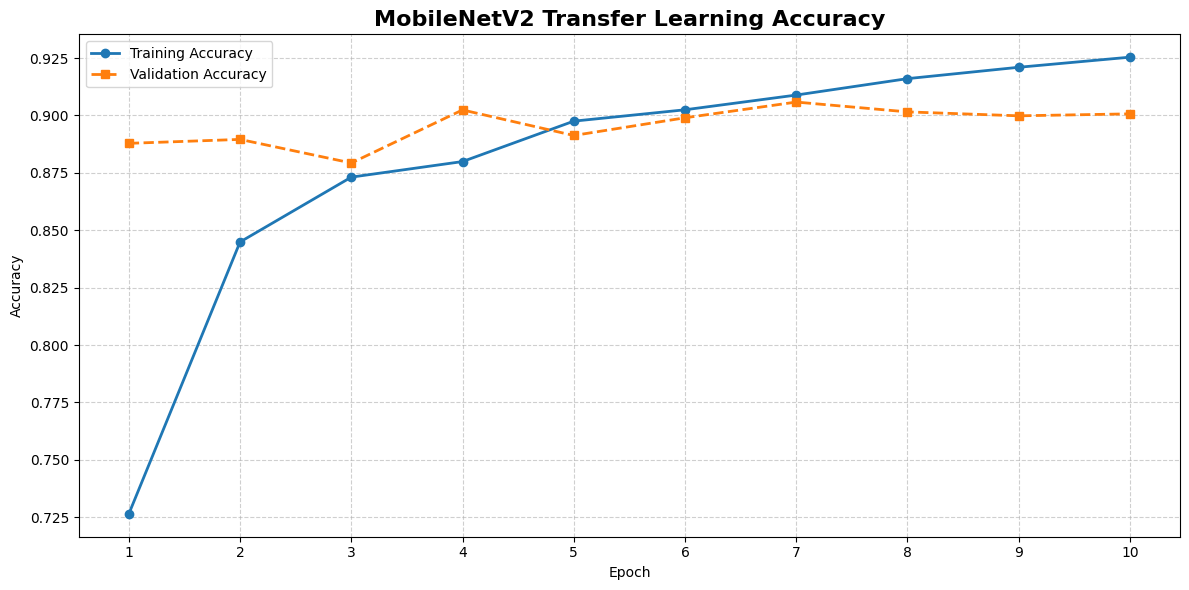

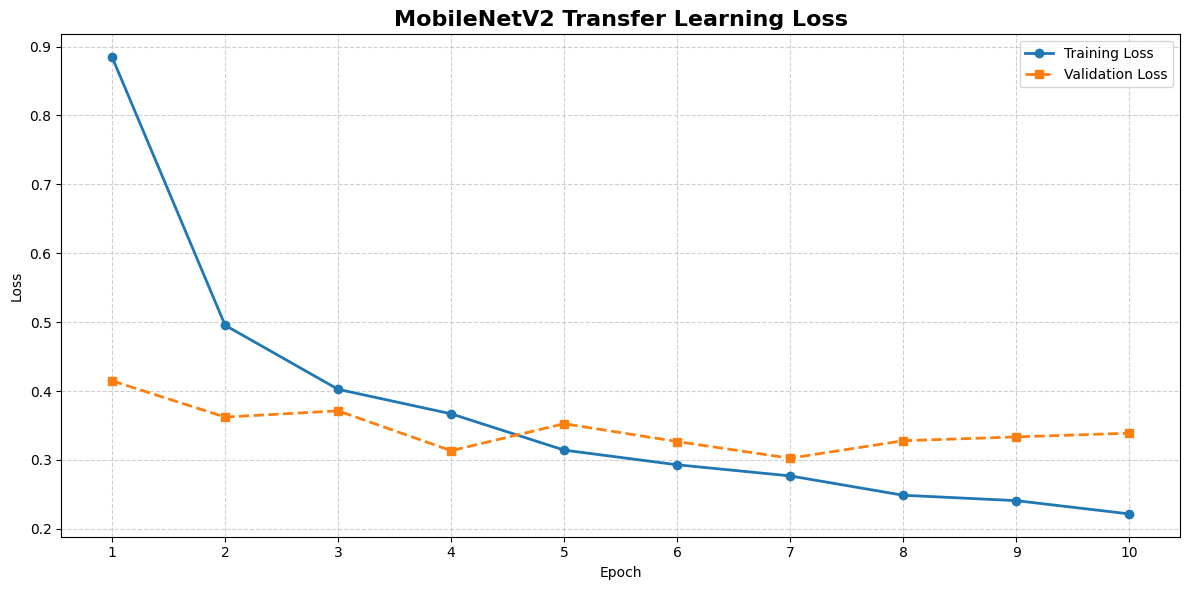

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 39: Plot Accuracy and Loss Curves
# ============================================================

acc = transfer_history.history.get("accuracy", [])
val_acc = transfer_history.history.get("val_accuracy", [])
loss = transfer_history.history.get("loss", [])
val_loss = transfer_history.history.get("val_loss", [])

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, acc, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="s", linewidth=2, linestyle="--", label="Validation Accuracy")
plt.title("MobileNetV2 Transfer Learning Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs_range, val_loss, marker="s", linewidth=2, linestyle="--", label="Validation Loss")
plt.title("MobileNetV2 Transfer Learning Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 40: Evaluate Transfer Model on Test Data
# ============================================================

print("=" * 70)
print("Evaluating MobileNetV2 Transfer Learning Model on Test Dataset")
print("=" * 70)

transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("TRANSFER LEARNING TEST PERFORMANCE")
print("=" * 70)
print(f"Model              : MobileNetV2")
print(f"Strategy           : Frozen Base Feature Extraction")
print(f"Test Accuracy      : {transfer_test_accuracy:.4f}")
print(f"Test Loss          : {transfer_test_loss:.4f}")
print(f"Training Time (sec): {transfer_training_time:.2f}")
print(f"Training Time (min): {transfer_training_time / 60:.2f}")
print("=" * 70)

Evaluating MobileNetV2 Transfer Learning Model on Test Dataset
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 410ms/step - accuracy: 0.9023 - loss: 0.3258
TRANSFER LEARNING TEST PERFORMANCE
Model              : MobileNetV2
Strategy           : Frozen Base Feature Extraction
Test Accuracy      : 0.9023
Test Loss          : 0.3258
Training Time (sec): 763.28
Training Time (min): 12.72


In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 41: Classification Report (Final Polished Version)
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Reset generator to ensure correct order
test_generator.reset()

# Predictions
transfer_pred_probs = transfer_model.predict(
    test_generator,
    verbose=1
)

transfer_pred_classes = np.argmax(transfer_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class labels (safe ordering)
class_labels = list(test_generator.class_indices.keys())

# Generate classification report
transfer_report_dict = classification_report(
    y_true,
    transfer_pred_classes,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
transfer_report_df = pd.DataFrame(transfer_report_dict).transpose()

print("=" * 70)
print("TRANSFER LEARNING CLASSIFICATION REPORT")
print("=" * 70)

# Display clean rounded table
display(transfer_report_df.round(4))

print("=" * 70)

37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step
TRANSFER LEARNING CLASSIFICATION REPORT


,precision,recall,f1-score,support
badminton,0.8296,0.8116,0.8205,138.0000
basketball,0.9538,0.8493,0.8986,73.0000
boxing,0.9510,0.9238,0.9372,105.0000
chess,0.9054,0.9571,0.9306,70.0000
cricket,0.9355,0.8788,0.9062,99.0000
football,0.8740,0.9487,0.9098,117.0000
formula1,0.9608,0.9703,0.9655,101.0000
hockey,0.8272,0.7976,0.8121,84.0000
shooting,0.8780,0.9114,0.8944,79.0000
swimming,0.9899,0.9608,0.9751,102.0000


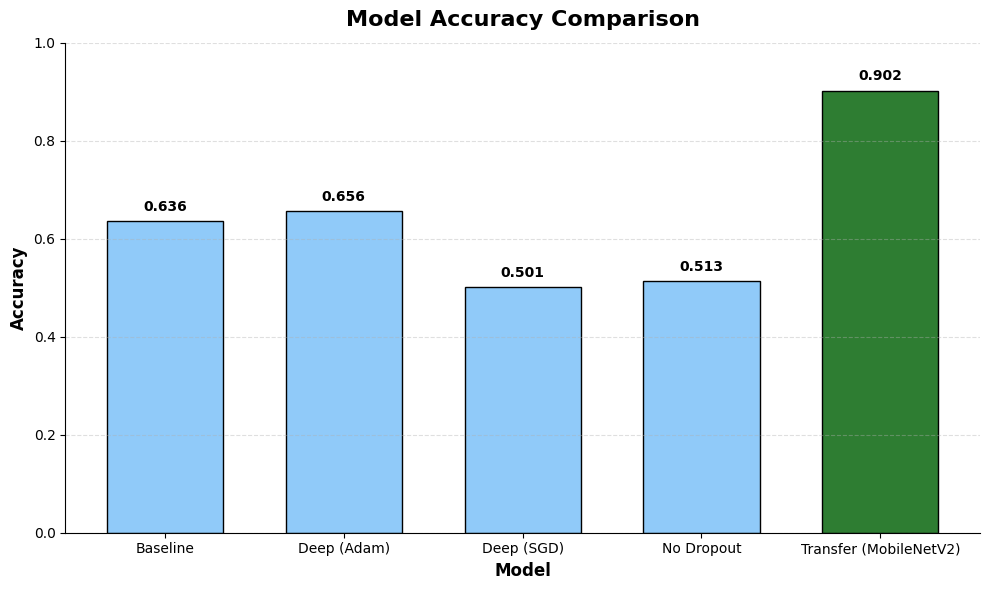

In [ ]:
# ============================================================
# Phase 10: Model Accuracy Comparison Plot (Final Polished)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = [
    "Baseline",
    "Deep (Adam)",
    "Deep (SGD)",
    "No Dropout",
    "Transfer (MobileNetV2)"
]

accuracies = [
    test_accuracy,
    deep_test_accuracy,
    sgd_test_accuracy,
    no_dropout_accuracy,
    transfer_test_accuracy
]

# Colors: highlight best (Transfer) in green, others in blue
colors = ["#90CAF9"] * 4 + ["#2E7D32"]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor="black", width=0.65)

# Titles & labels
plt.title("Model Accuracy Comparison", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Model", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate values
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.015,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Clean spines
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

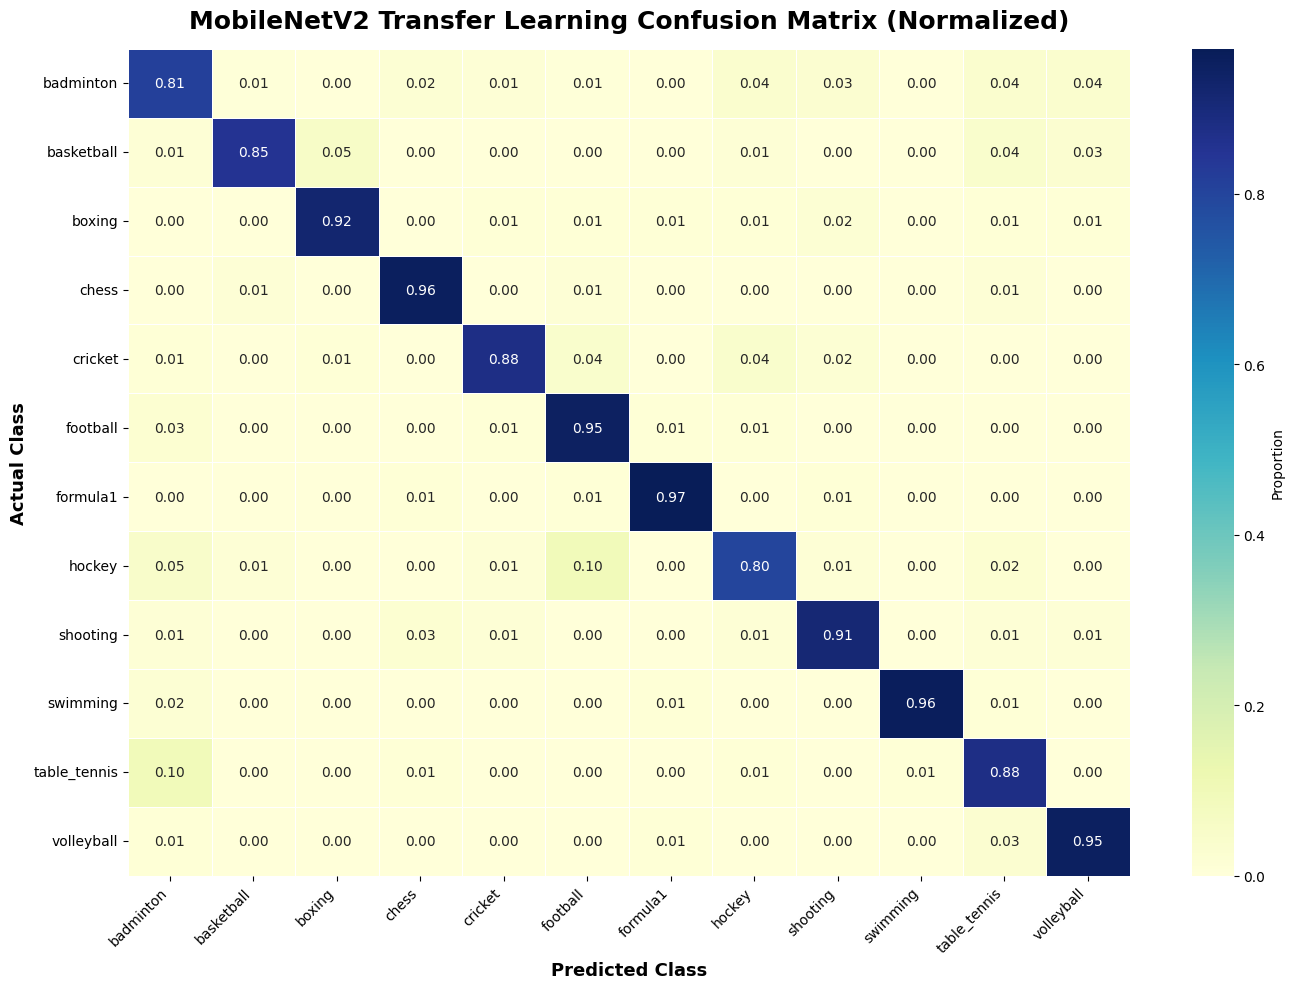

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 42: Confusion Matrix (Final Premium Version)
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm_transfer = confusion_matrix(y_true, transfer_pred_classes)

# Normalize (avoid division by zero just in case)
cm_normalized = cm_transfer.astype('float') / np.maximum(cm_transfer.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",  # nicer color scheme
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("MobileNetV2 Transfer Learning Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

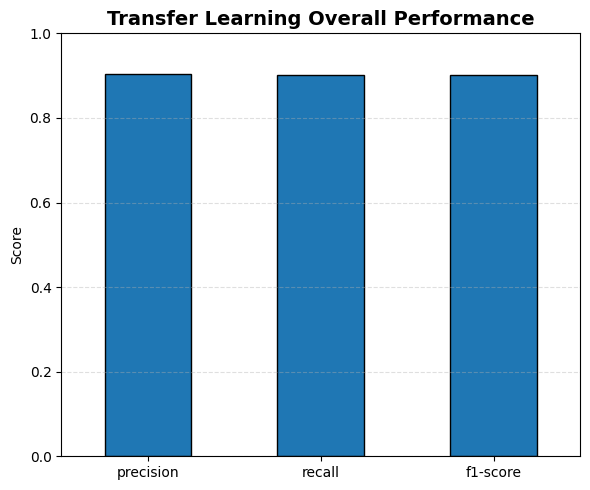

In [ ]:
# ============================================================
# Transfer Learning Metrics Visualization (Fixed)
# ============================================================

import matplotlib.pyplot as plt

# Take weighted average row (best for report)
metrics = transfer_report_df.loc["weighted avg", ["precision", "recall", "f1-score"]]

metrics.plot(kind="bar", figsize=(6, 5), edgecolor="black")

plt.title("Transfer Learning Overall Performance", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

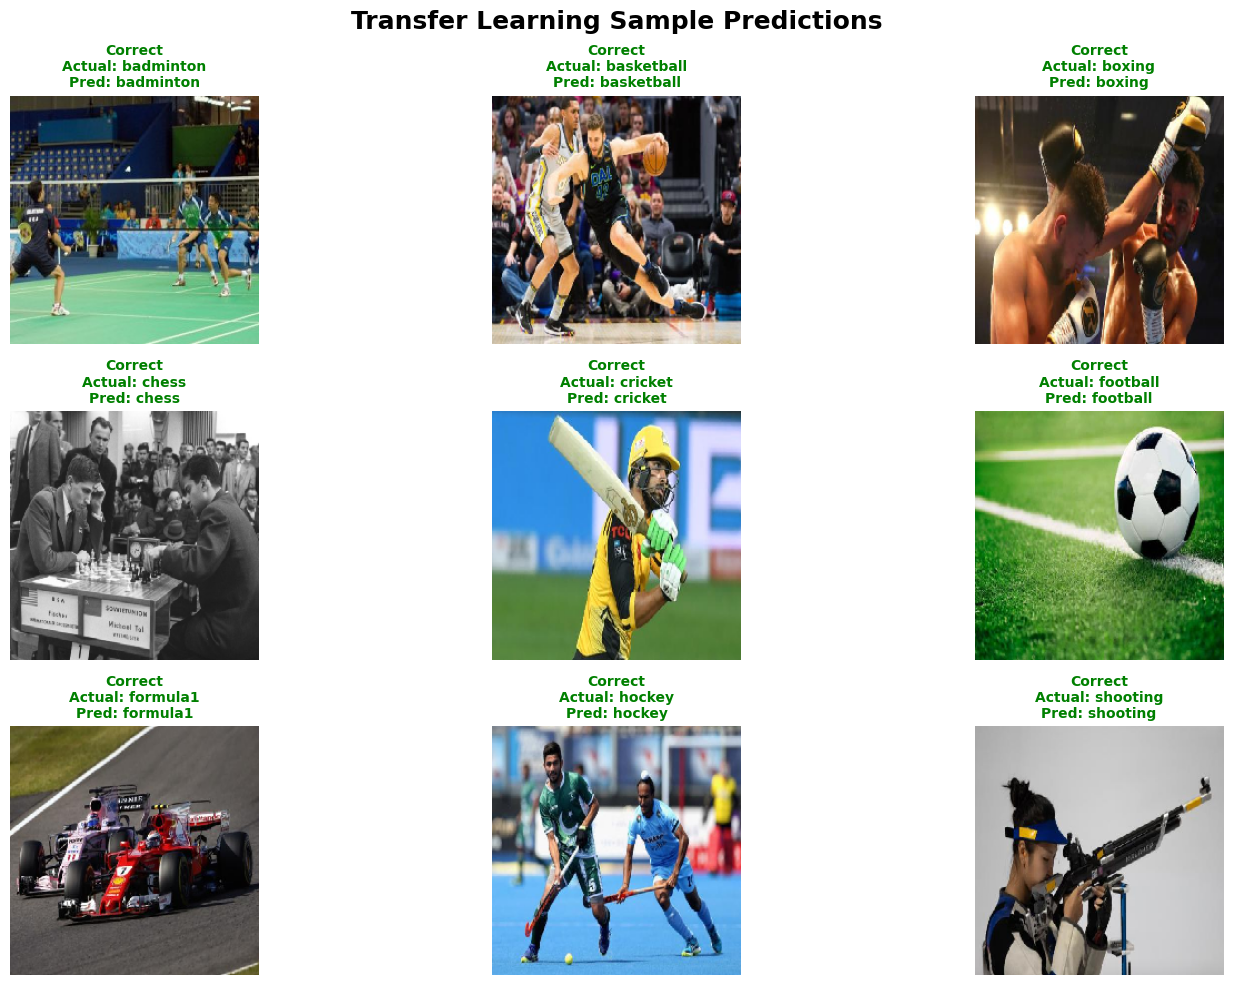

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 43: Sample Predictions
# ============================================================

test_generator.reset()

sample_images = []
sample_true_labels = []
sample_pred_labels = []

seen_classes = set()

for images, labels in test_generator:
    preds = transfer_model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    for i in range(len(images)):
        true_label = class_labels[true_classes[i]]
        pred_label = class_labels[pred_classes[i]]

        if true_label not in seen_classes:
            sample_images.append(images[i])
            sample_true_labels.append(true_label)
            sample_pred_labels.append(pred_label)
            seen_classes.add(true_label)

        if len(sample_images) >= 9:
            break

    if len(sample_images) >= 9:
        break

plt.figure(figsize=(16, 10))

for i in range(len(sample_images)):
    is_correct = sample_true_labels[i] == sample_pred_labels[i]
    color = "green" if is_correct else "red"
    status = "Correct" if is_correct else "Wrong"

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(
        f"{status}\nActual: {sample_true_labels[i]}\nPred: {sample_pred_labels[i]}",
        color=color,
        fontsize=10,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Transfer Learning Sample Predictions", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

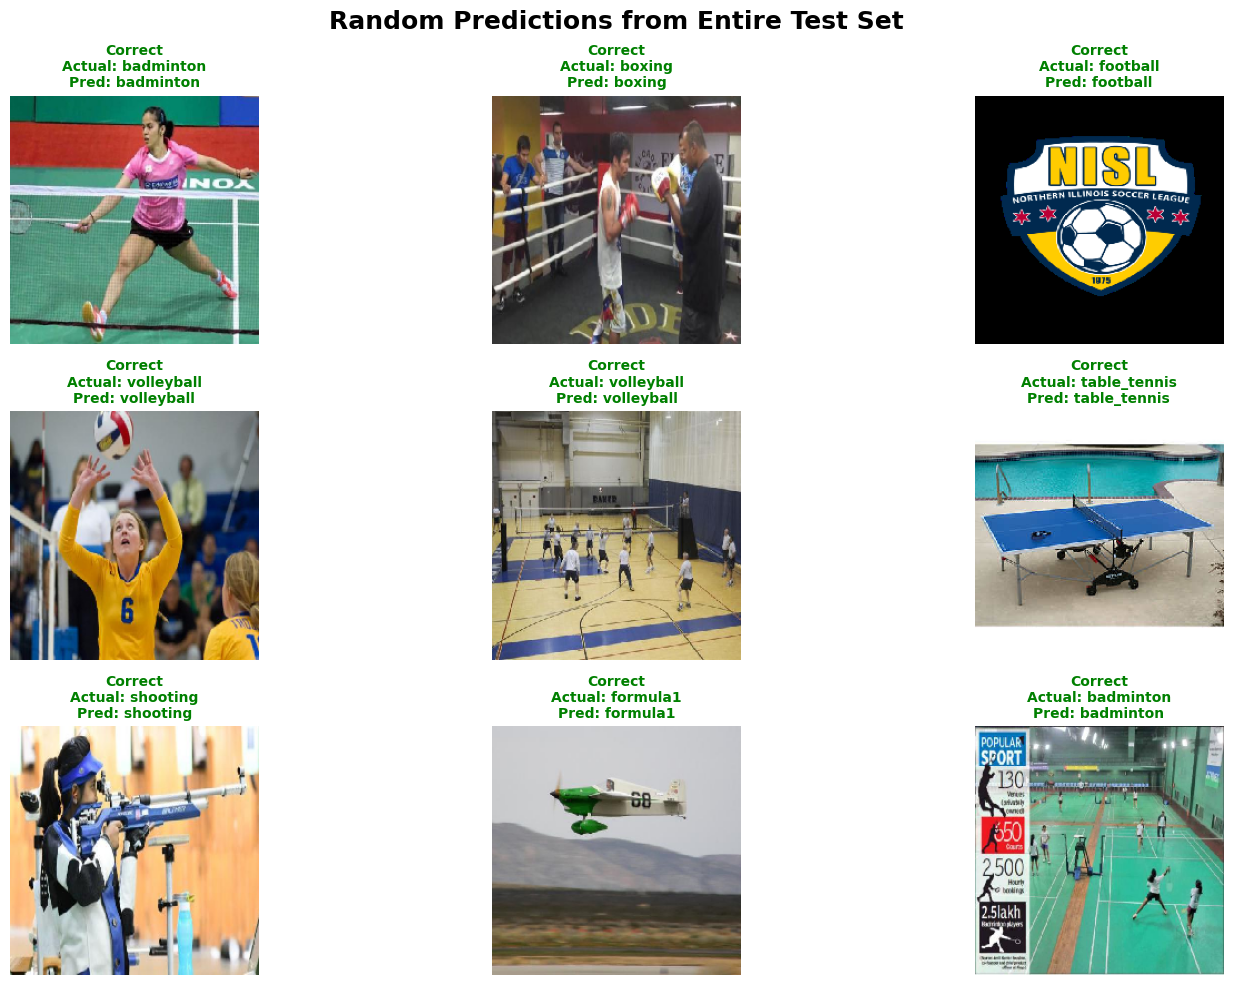

In [ ]:
# ============================================================
# Extra: Truly Random Predictions from Entire Test Set
# ============================================================

import numpy as np
import random

test_generator.reset()

all_images = []
all_true = []
all_pred = []

# Collect from entire test set
for images, labels in test_generator:
    preds = transfer_model.predict(images, verbose=0)

    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    for i in range(len(images)):
        all_images.append(images[i])
        all_true.append(class_labels[true_classes[i]])
        all_pred.append(class_labels[pred_classes[i]])

    if len(all_images) >= test_generator.samples:
        break

# Pick truly random 9 samples from whole dataset
indices = random.sample(range(len(all_images)), 9)

plt.figure(figsize=(16, 10))

for i, idx in enumerate(indices):
    img = all_images[idx]
    true_label = all_true[idx]
    pred_label = all_pred[idx]

    is_correct = true_label == pred_label
    color = "green" if is_correct else "red"
    status = "Correct" if is_correct else "Wrong"

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"{status}\nActual: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=10,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Random Predictions from Entire Test Set", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 10: Final Model Comparison Table (Final Version)
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN (Adam)",
        "Deep CNN (SGD)",
        "Deep CNN (No Dropout)",
        "Transfer Learning (MobileNetV2)"
    ],
    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy,
        sgd_test_accuracy,
        no_dropout_accuracy,
        transfer_test_accuracy
    ],
    "Test Loss": [
        test_loss,
        deep_test_loss,
        sgd_test_loss,
        no_dropout_loss,
        transfer_test_loss
    ],
    "Training Time (sec)": [
        baseline_training_time,
        deep_training_time,
        sgd_training_time,
        no_dropout_time,
        transfer_training_time
    ]
})

# Clean formatting
final_comparison = final_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best accuracy
final_comparison = final_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 75)
print("FINAL MODEL PERFORMANCE COMPARISON (ALL MODELS)")
print("=" * 75)

display(final_comparison)

FINAL MODEL PERFORMANCE COMPARISON (ALL MODELS)


,Model,Test Accuracy,Test Loss,Training Time (sec)
0,Transfer Learning (MobileNetV2),0.9023,0.3258,763.28
1,Deep CNN (Adam),0.6559,1.1071,1500.08
2,Baseline CNN,0.6355,1.4685,1497.18
3,Deep CNN (No Dropout),0.5132,1.5163,498.75
4,Deep CNN (SGD),0.5013,1.4360,1497.03
